In [1]:
# You must NOT modify this chunk of code at all!
import numpy as np
import random
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches
import time

# You must NOT modify the Environment class
class Environment:

  DIRTY = 1
  CLEAN = 2
  BLOCKED = 3
  VISITED = 4

  # You must NOT modify the constructor
  def __init__(self, nRows, nCols, seed):
    np.random.seed(seed)
    self.__environment = np.random.randint(4, size = (nRows, nCols))
    self.__x = 0
    self.__y = 0
    self.__nRows = nRows
    self.__nCols = nCols
    self.__stateID = -1
    self.__environment[0, 0] = Environment.CLEAN
    self.__updateState()
    self.__plot()

  # You must NOT modify the __plot function
  def __plot(self):
    print("State " + str(self.__stateID))
    self.__stateID += 1
    fig, ax = plt.subplots()
    ax.set_xlim(0, self.__nCols)
    ax.set_ylim(0, self.__nRows)
    for x in range(self.__nCols + 1):
      ax.axvline(x, color = "black", linestyle = "-", linewidth = 1)
    for y in range(self.__nRows + 1):
      ax.axhline(y, color = "black", linestyle = "-", linewidth = 1)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.text(self.__x + 0.5, self.__y + 0.5, "X", ha = "center", va = "center", fontsize = 30, color = "blue")
    for j in range(self.__nRows):
      for i in range(self.__nCols):
        match self.__environment[j, i]:
          case Environment.DIRTY:
            rect = patches.Rectangle((i, j), 1, 1, linewidth = 0, edgecolor = "none", facecolor = "lightgrey")
            ax.add_patch(rect)
          case Environment.BLOCKED:
            rect = patches.Rectangle((i, j), 1, 1, linewidth = 0, edgecolor = "none", facecolor = "black")
            ax.add_patch(rect)
          case Environment.VISITED:
            rect = patches.Rectangle((i, j), 1, 1, linewidth = 0, edgecolor = "none", facecolor = "lightgreen")
            ax.add_patch(rect)
    plt.show()

  # You must NOT modify the __updateState function
  def __updateState(self):
    self.__dirt = (self.__environment[self.__y, self.__x] == Environment.DIRTY)
    self.__obstacleLeft = not (self.__x - 1 >= 0 and self.__environment[self.__y, self.__x - 1] != Environment.BLOCKED)
    self.__obstacleRight = not (self.__x + 1 < self.__nCols and self.__environment[self.__y, self.__x + 1] != Environment.BLOCKED)
    self.__obstacleDown = not (self.__y - 1 >= 0 and self.__environment[self.__y - 1, self.__x] != Environment.BLOCKED)
    self.__obstacleUp = not (self.__y + 1 < self.__nRows and self.__environment[self.__y + 1, self.__x] != Environment.BLOCKED)

  # You must NOT modify the getState function
  def getState(self):
    self.__updateState()
    return {"dirt" : self.__dirt, "obstacleLeft": self.__obstacleLeft, "obstacleRight": self.__obstacleRight, "obstacleUp": self.__obstacleUp, "obstacleDown": self.__obstacleDown}

  # You must NOT modify the run function
  def run(self, action):
    x = self.__x
    y = self.__y
    match action:
      case "clean":
        if self.__environment[self.__y, self.__x] == Environment.DIRTY:
          self.__environment[y, x] = Environment.CLEAN
      case "left":
        if not self.__obstacleLeft:
          self.__x = self.__x - 1
      case "right":
        if not self.__obstacleRight:
          self.__x = self.__x + 1
      case "up":
        if not self.__obstacleUp:
          self.__y = self.__y + 1
      case "down":
        if not self.__obstacleDown:
          self.__y = self.__y - 1
      case _:
        None
    self.__environment[y, x] = Environment.VISITED
    self.__plot()

  # You must NOT modify the evaluate function
  def evaluate(self):
    sum = 0
    for j in range(self.__nRows):
      for i in range(self.__nCols):
        if self.__environment[j, i] == Environment.DIRTY:
          sum = sum + 1
    return self.__stateID, sum / (self.__nRows * self.__nCols)


In [8]:
# You must ppdate this chunk of code (the allowed parts, of course)!
class Agent:

  # You must update the constructor, but do no change the method's signature
  def __init__(self, seed):
    # Modify between lines
    # ======================
    # Initialize your agent.
    # Add as many components as you consider suitable.

    #Memory init
    self.pos = (0,0)
    self.visited = {(0,0)}
    self.reverse = []

    self.order = ["right", "up", "left", "down"]

    self.directions = {
        "right": (1, 0),
        "left":  (-1, 0),
        "up":    (0, 1),
        "down":  (0, -1),
    }
    self.opposites = {
        "right": "left",
        "left":  "right",
        "up":    "down",
        "down":  "up",
    }
    # ======================

  # You must NOT modify the __perceive function
  def __perceive(self, environment):
    return environment.getState()

  # You must update the __think function
  def __think(self, percepts):
    # Modify between lines
    # ======================
    # Define the agent's behavior
    # Recall that the percepts are provided as a dictionary.
    # So, you can access the different percepts using the proper keys:
    #
    # percepts["dirt"] returns if there is dirt in the agent's current position.
    # percepts["obstacleLeft"] returns if there is an object blocking the agent on the left of its current position.
    # percepts["obstacleRight"] returns if there is an object blocking the agent on the right of its current position.
    # percepts["obstacleUp"] returns if there is an object blocking the agent above its current position.
    # percepts["obstacleDown"] returns if there is an object blocking the agent below its current position.
    #
    # The available actions for the agent are "clean", "right", "left", "up", "down", and "stop".
    # clean. Cleans the cell where the agent is placed.
    # right. Tries to move the agent one cell to the right.
    # left. Tries to move the agent one cell to the left.
    # up. Tries to move the agent one cell up.
    # down. Tries to move the agent one cell down.
    # stop. Stops the simulation.
    #
    # You are allowed to use any strategy that you consider suitable so the vacuum cleaner works correctly.
    # Here, we provide some rules as an example, but you must modify this function accordingly

    #Clean if dirty
    if percepts["dirt"]:
      return "clean"

    #Get possible moves
    possible_moves = {
  "left":  not percepts["obstacleLeft"],
  "right": not percepts["obstacleRight"],
  "up":    not percepts["obstacleUp"],
  "down":  not percepts["obstacleDown"],
}
    #Current postition
    x, y = self.pos

    #Select posible move
    for d in self.order:
      if not possible_moves[d]:
        continue

      #Get selected move`s direction
      dx, dy = self.directions[d]
      #Actual pos + selected move`s direction
      nxt = (x + dx, y + dy)
      #If not visited, save the opposite move for reversal, update the actual position and save as visited
      if nxt not in self.visited:
        self.reverse.append(self.opposites[d])
        self.pos = nxt
        self.visited.add(nxt)
        return d

    #If there are no new tiles in th actual position, move back or finish
    if self.reverse:
      d = self.reverse.pop()
      dx, dy = self.directions[d]
      self.pos = (x + dx, y + dy)
      return d

    #Stop if finished
    return "stop"
    # ======================

  # You must NOT modify the start function
  def start(self, environment, maxSteps):
    for i in range(maxSteps):
      percepts = self.__perceive(environment)
      action = self.__think(percepts)
      print("Action = " + action + "\n")
      if action == "stop":
        break
      environment.run(action)


State -1


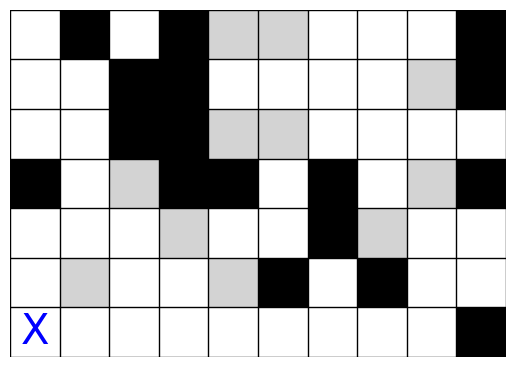

Action = right

State 0


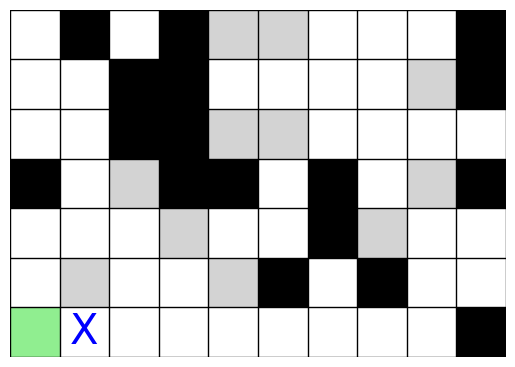

Action = right

State 1


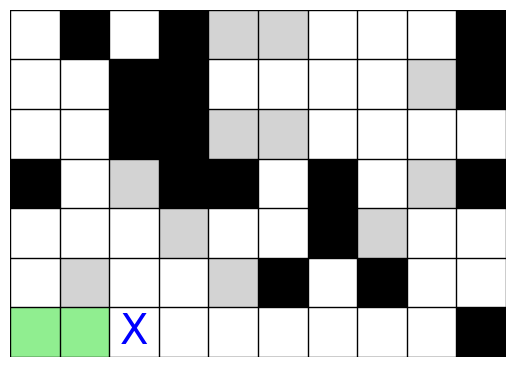

Action = right

State 2


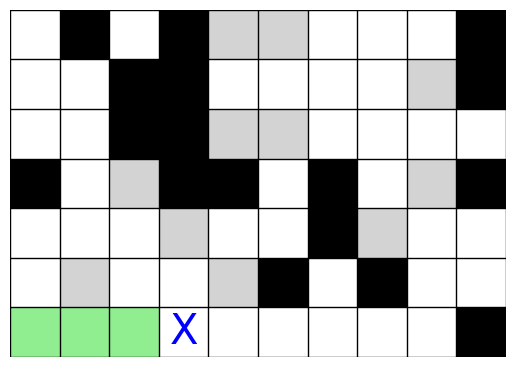

Action = right

State 3


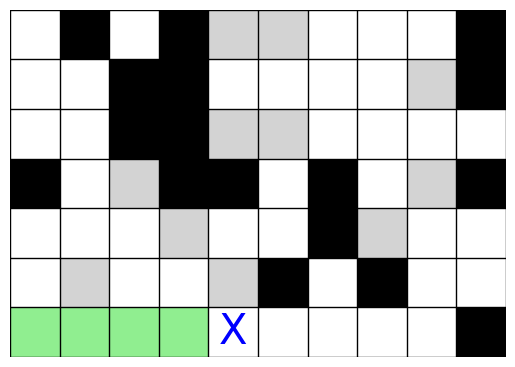

Action = right

State 4


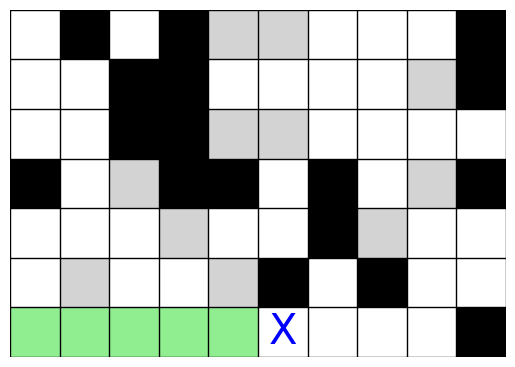

Action = right

State 5


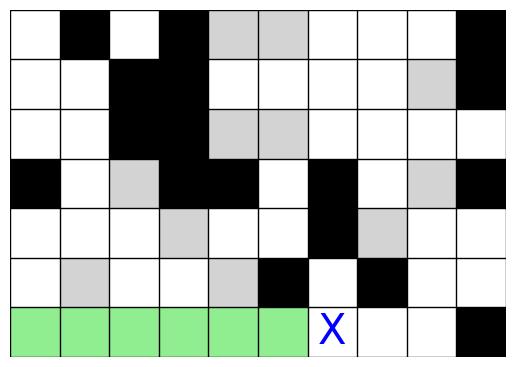

Action = right

State 6


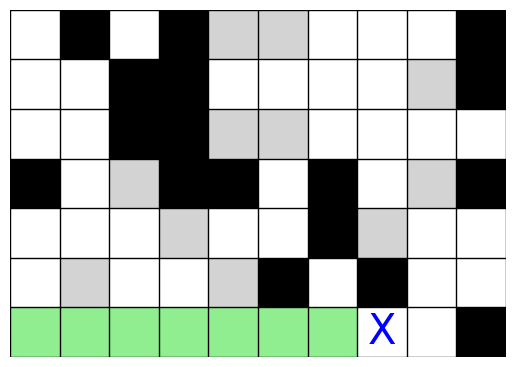

Action = right

State 7


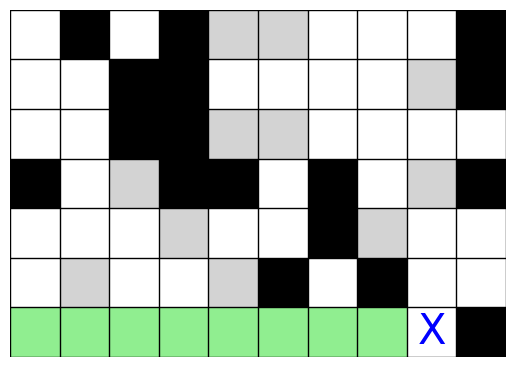

Action = up

State 8


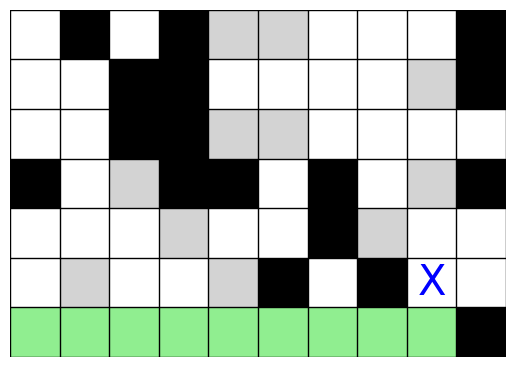

Action = right

State 9


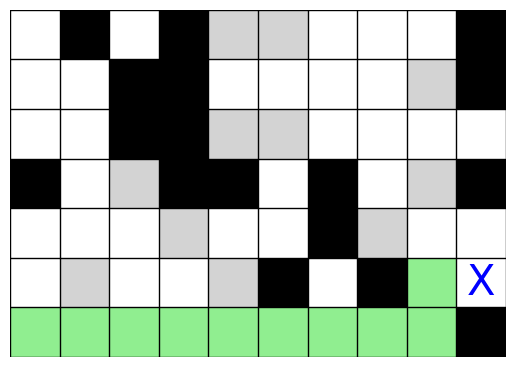

Action = up

State 10


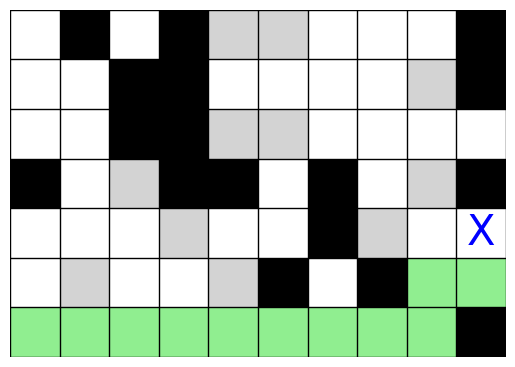

Action = left

State 11


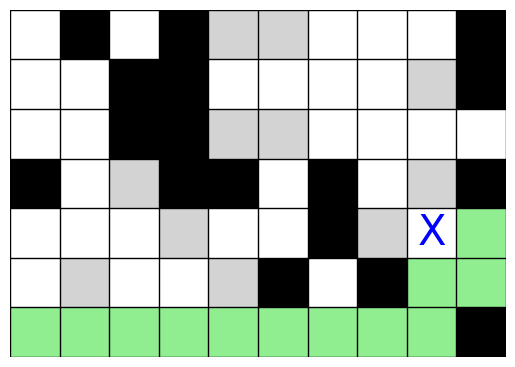

Action = up

State 12


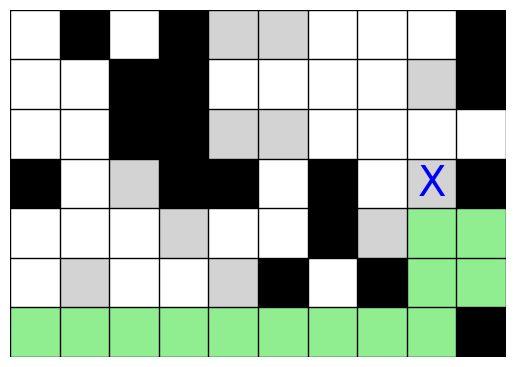

Action = clean

State 13


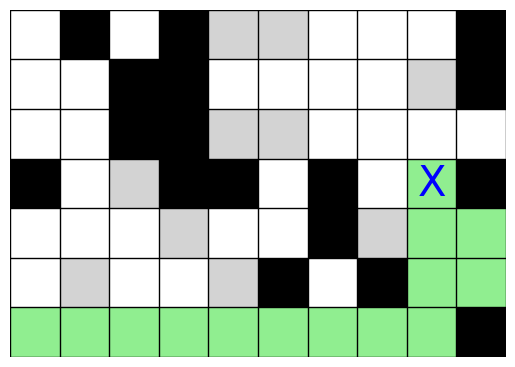

Action = up

State 14


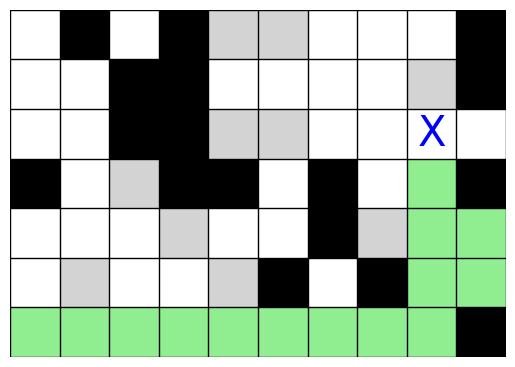

Action = right

State 15


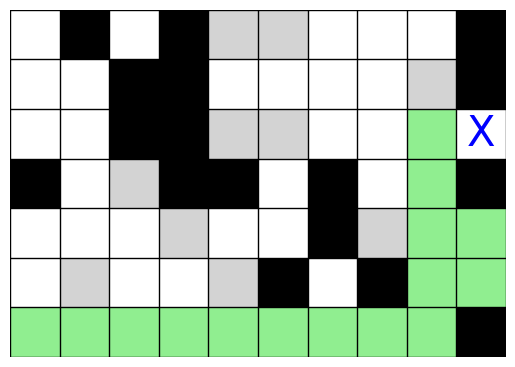

Action = left

State 16


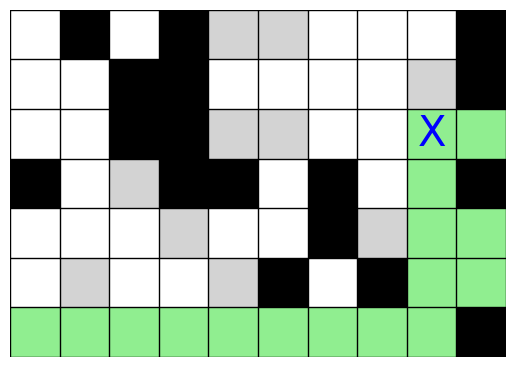

Action = up

State 17


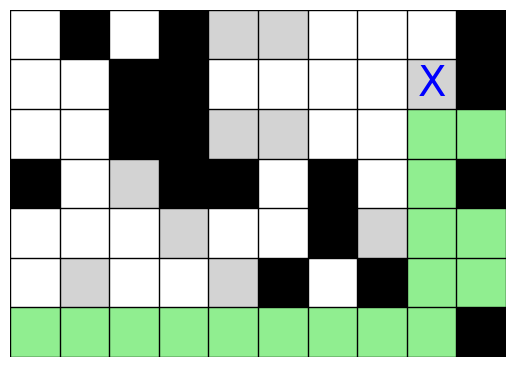

Action = clean

State 18


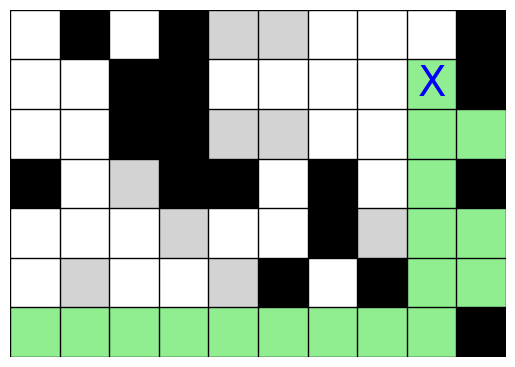

Action = up

State 19


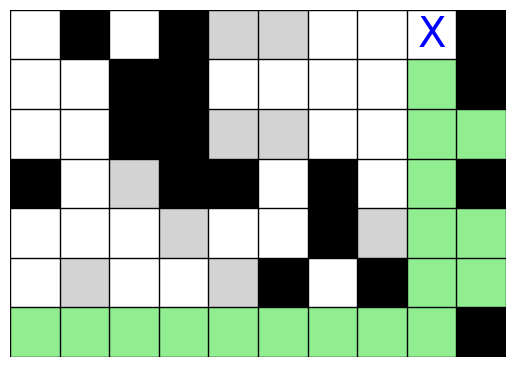

Action = left

State 20


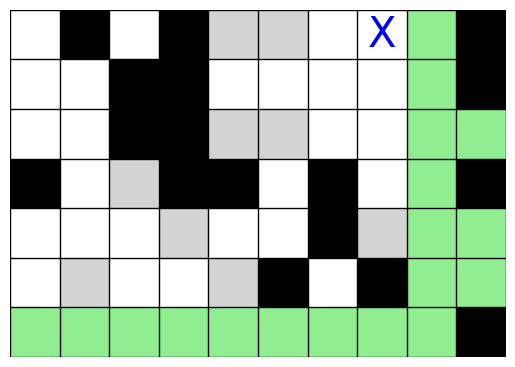

Action = left

State 21


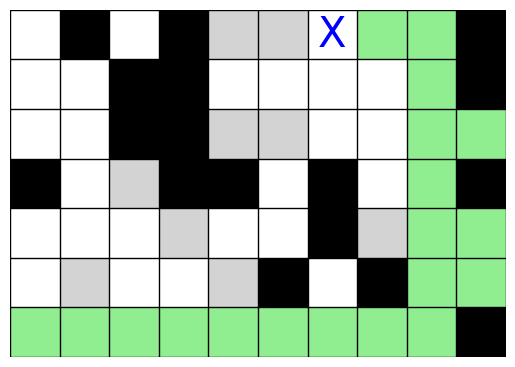

Action = left

State 22


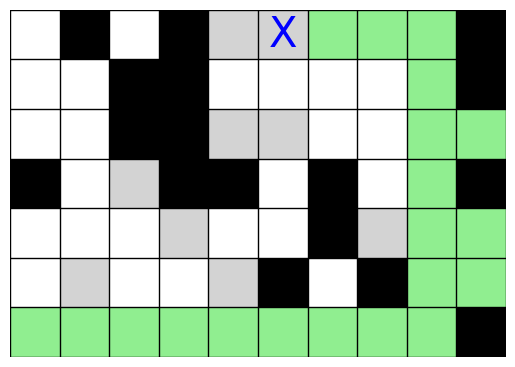

Action = clean

State 23


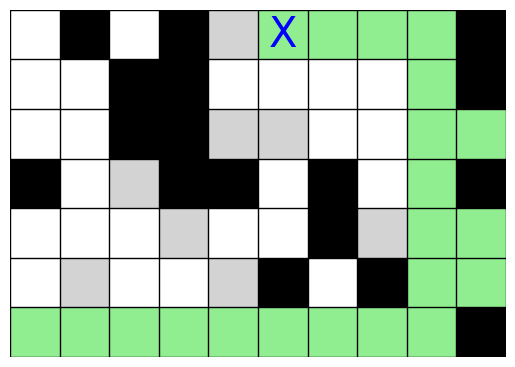

Action = left

State 24


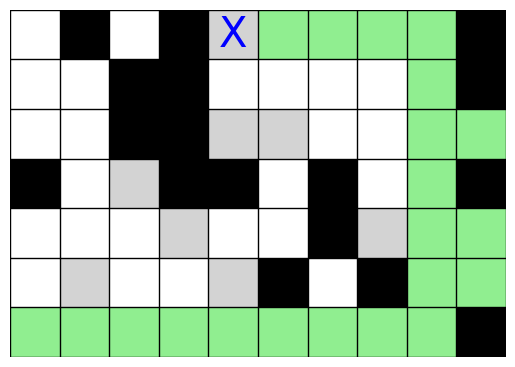

Action = clean

State 25


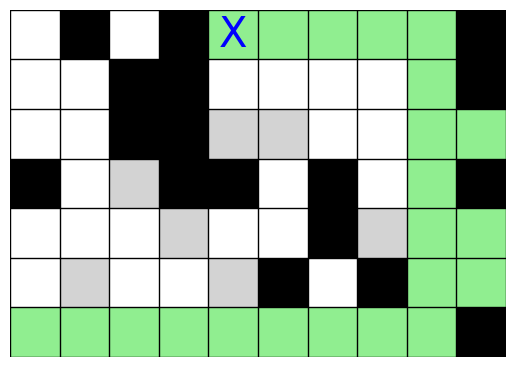

Action = down

State 26


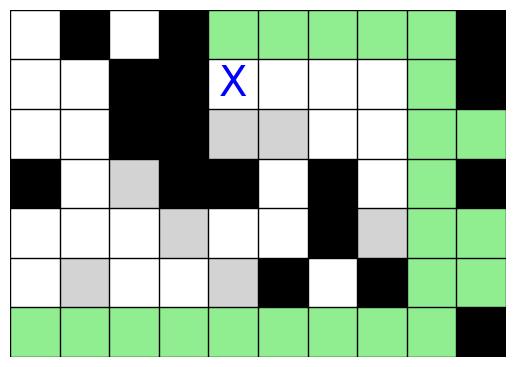

Action = right

State 27


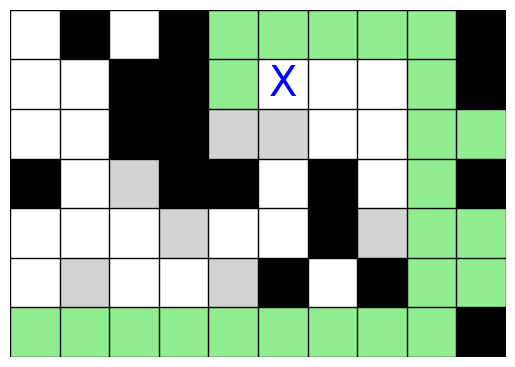

Action = right

State 28


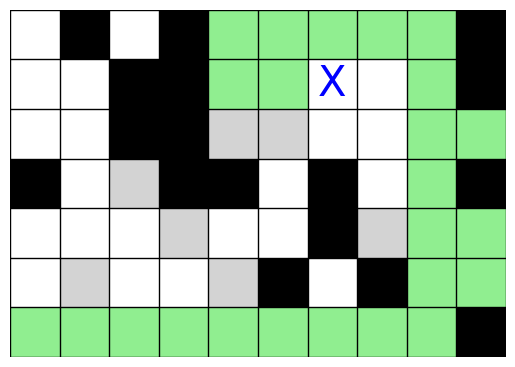

Action = right

State 29


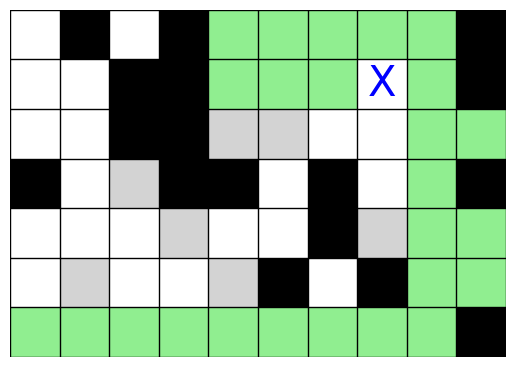

Action = down

State 30


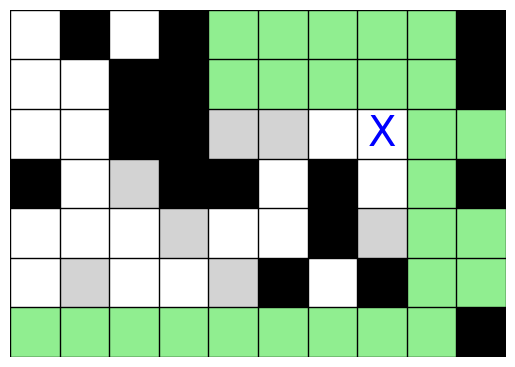

Action = left

State 31


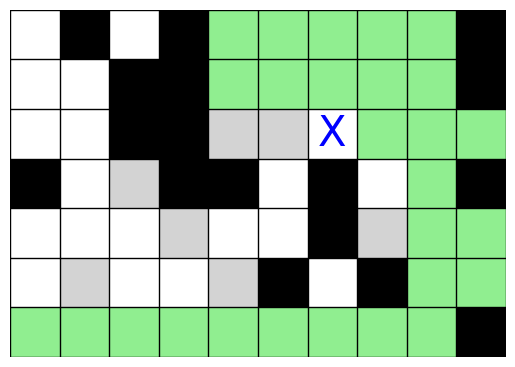

Action = left

State 32


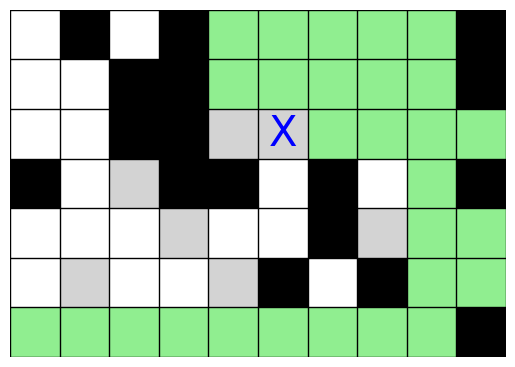

Action = clean

State 33


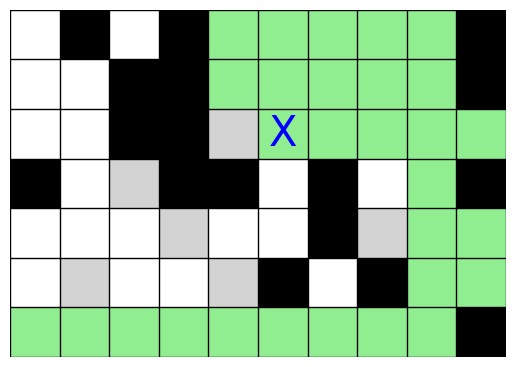

Action = left

State 34


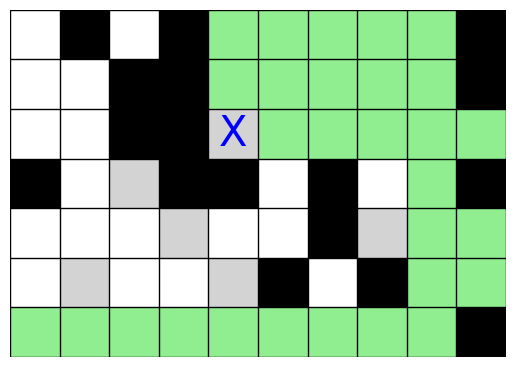

Action = clean

State 35


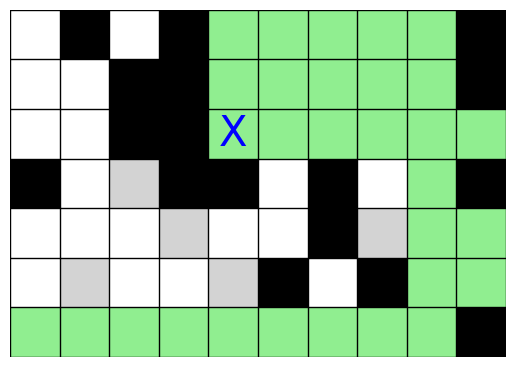

Action = right

State 36


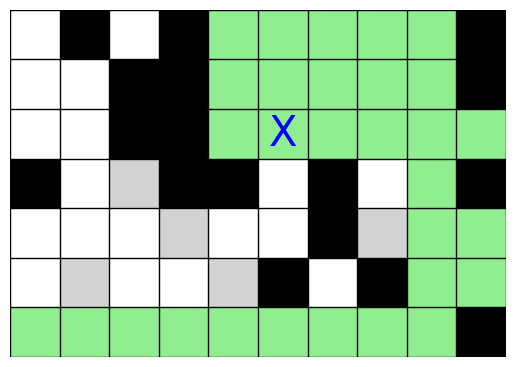

Action = down

State 37


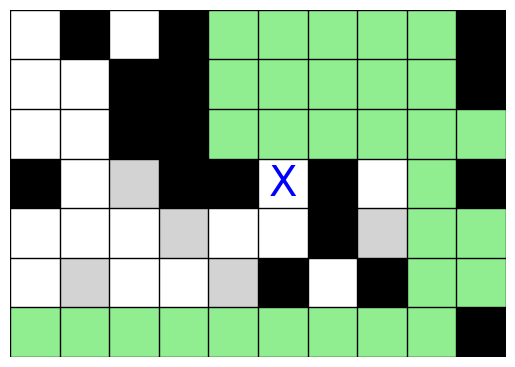

Action = down

State 38


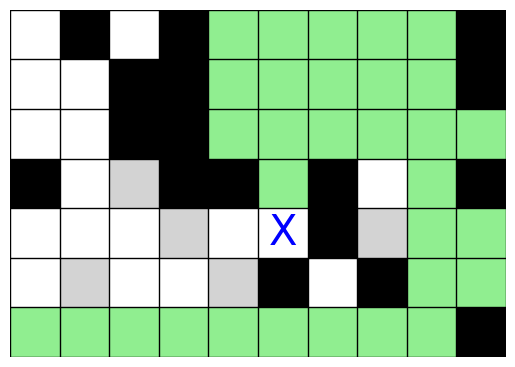

Action = left

State 39


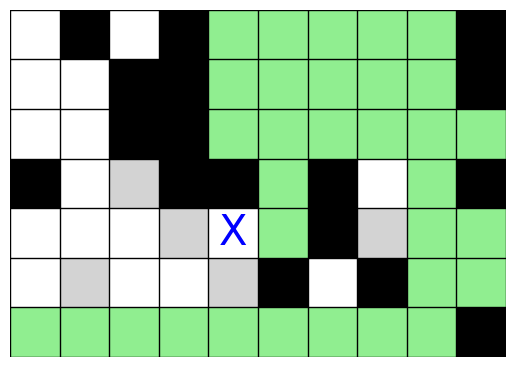

Action = left

State 40


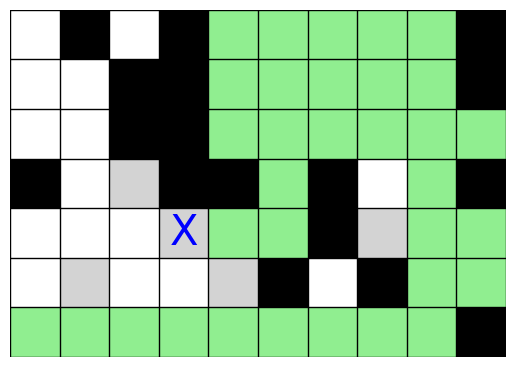

Action = clean

State 41


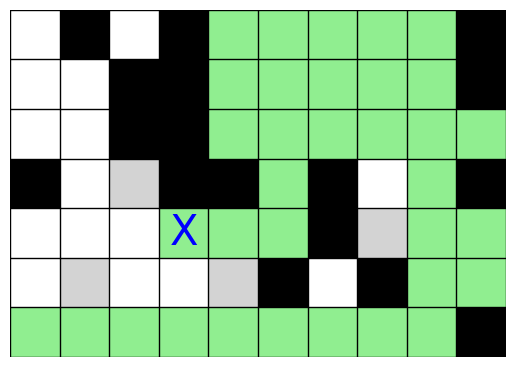

Action = left

State 42


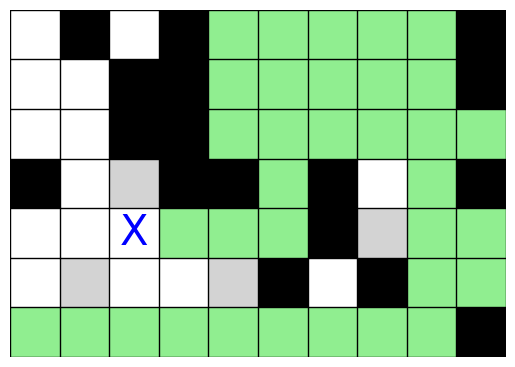

Action = up

State 43


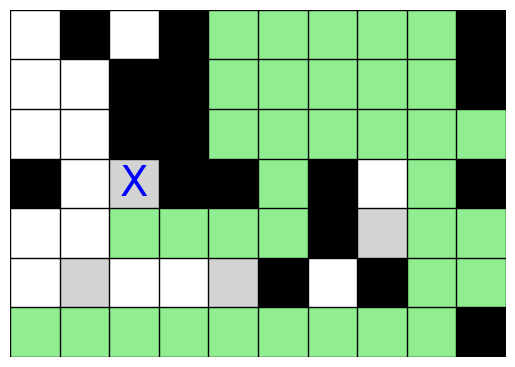

Action = clean

State 44


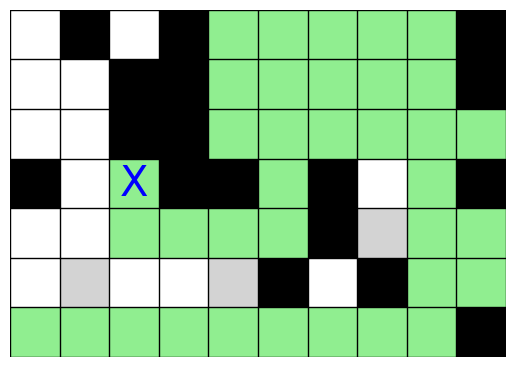

Action = left

State 45


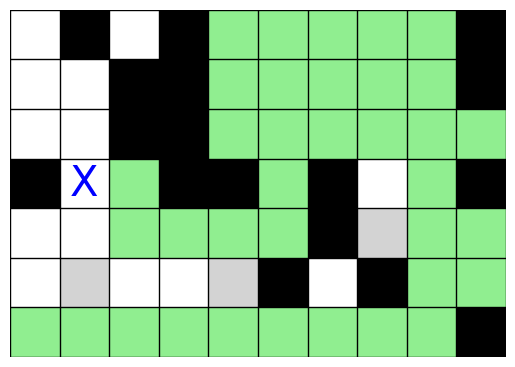

Action = up

State 46


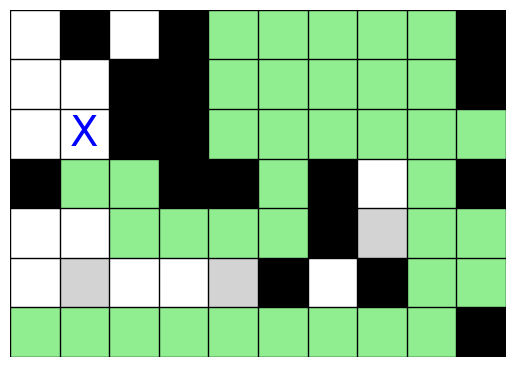

Action = up

State 47


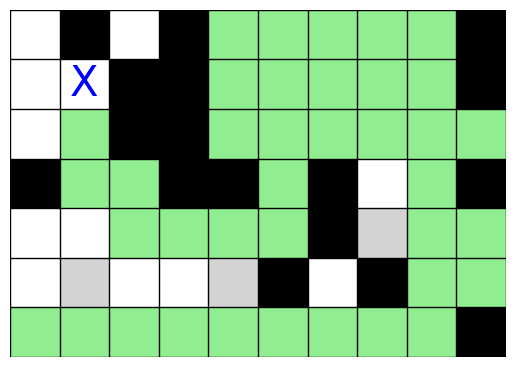

Action = left

State 48


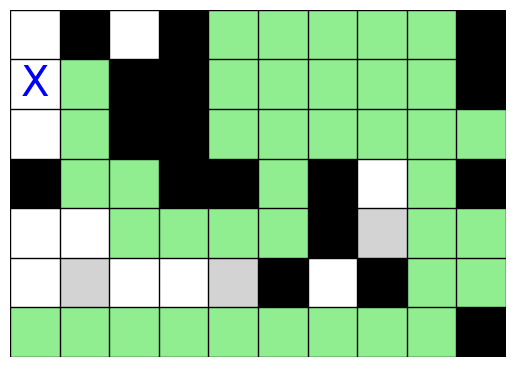

Action = up

State 49


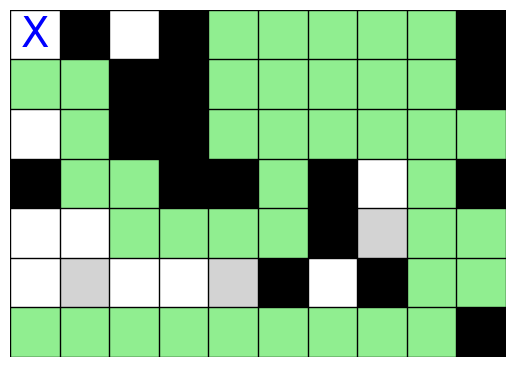

Action = down

State 50


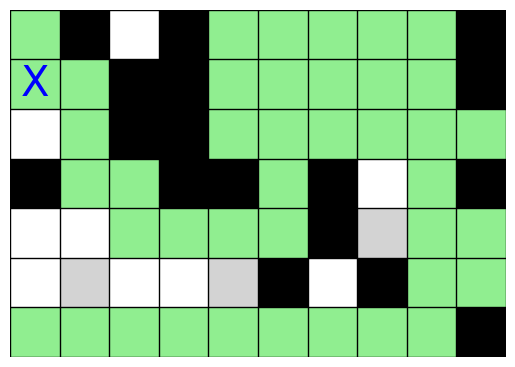

Action = down

State 51


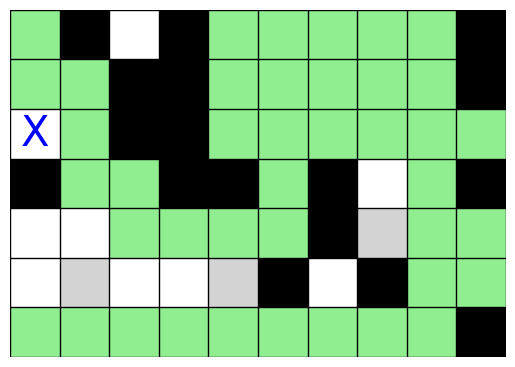

Action = up

State 52


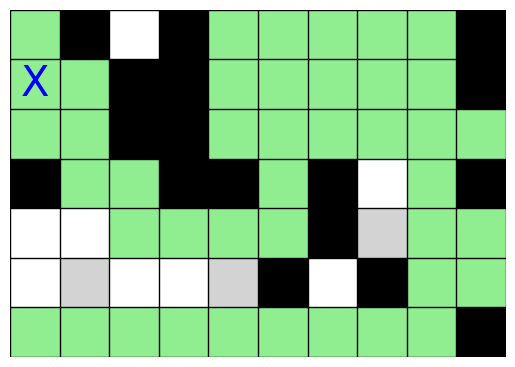

Action = right

State 53


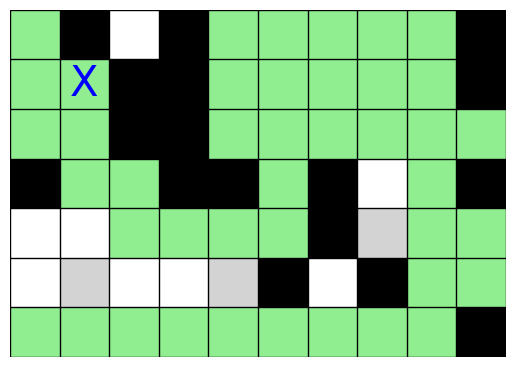

Action = down

State 54


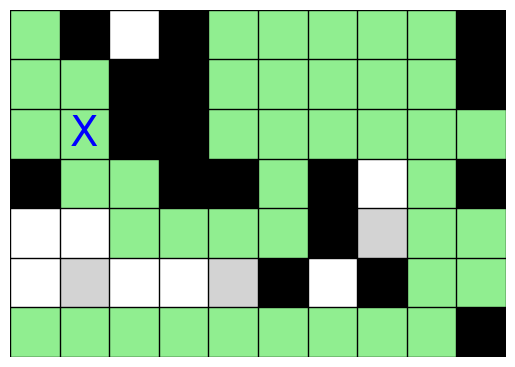

Action = down

State 55


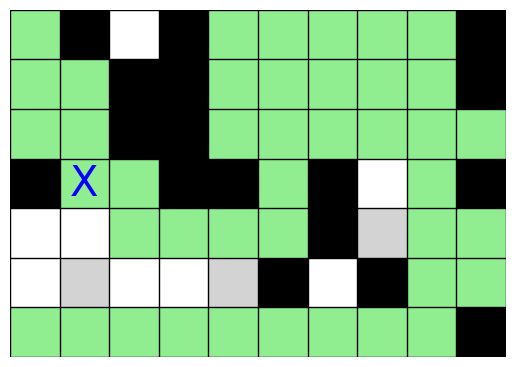

Action = down

State 56


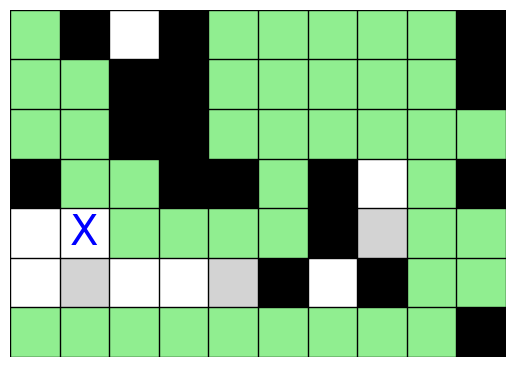

Action = left

State 57


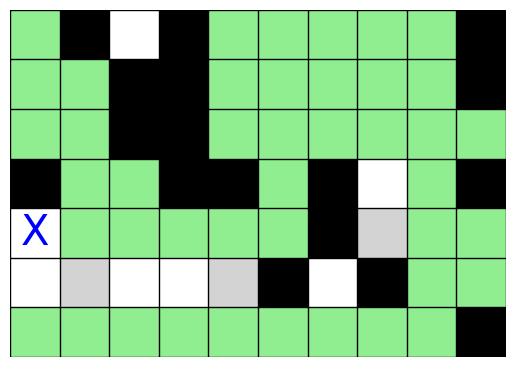

Action = down

State 58


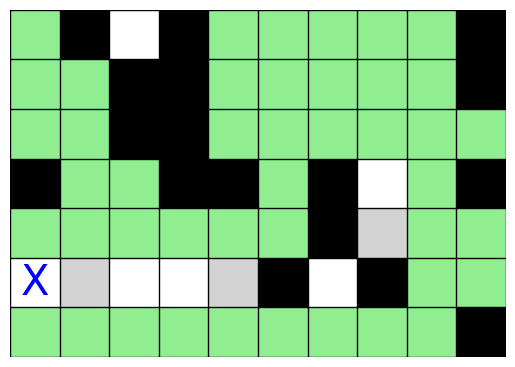

Action = right

State 59


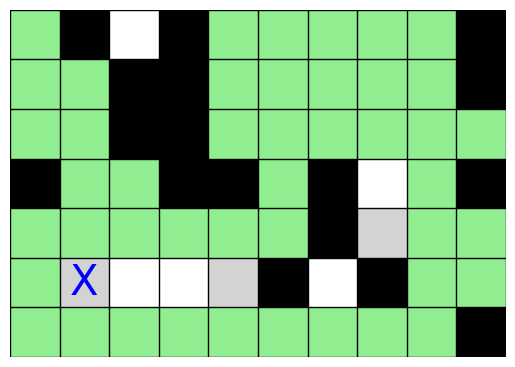

Action = clean

State 60


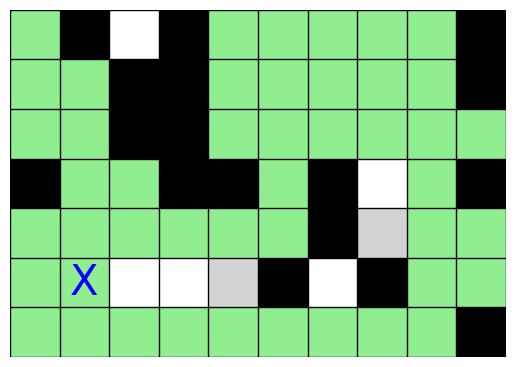

Action = right

State 61


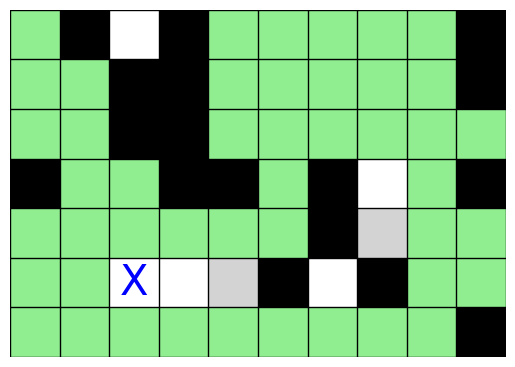

Action = right

State 62


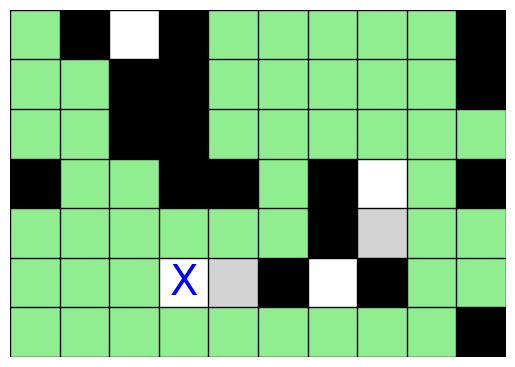

Action = right

State 63


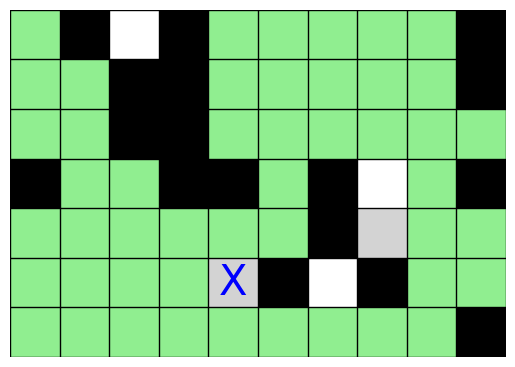

Action = clean

State 64


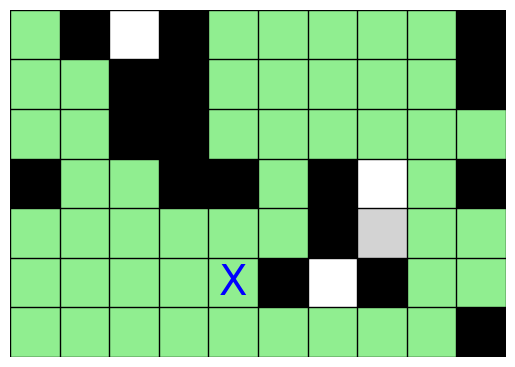

Action = left

State 65


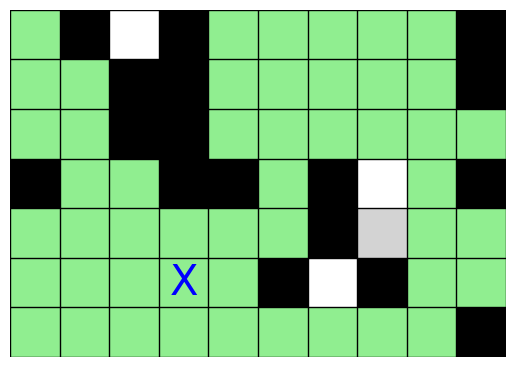

Action = left

State 66


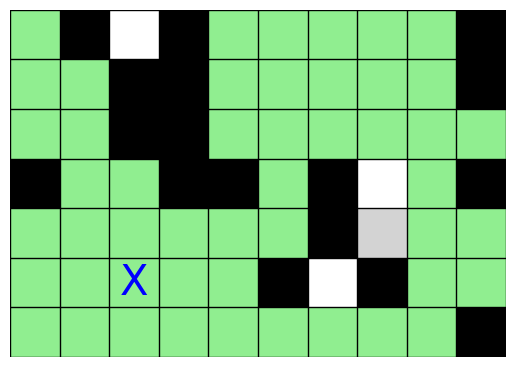

Action = left

State 67


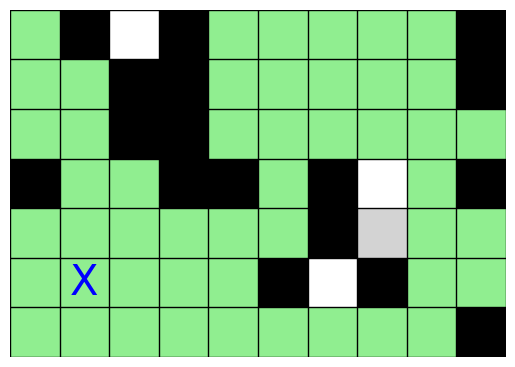

Action = left

State 68


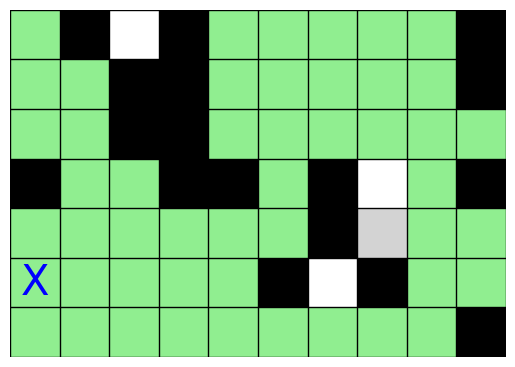

Action = up

State 69


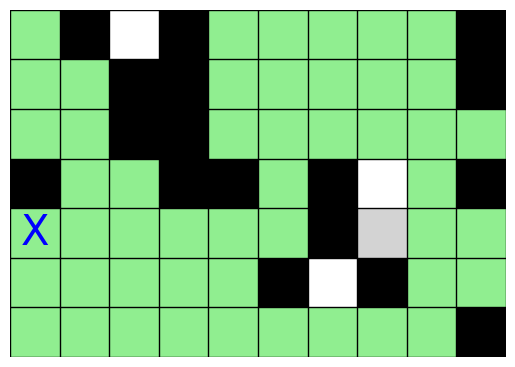

Action = right

State 70


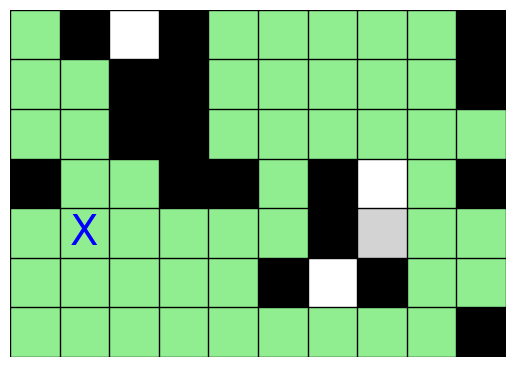

Action = up

State 71


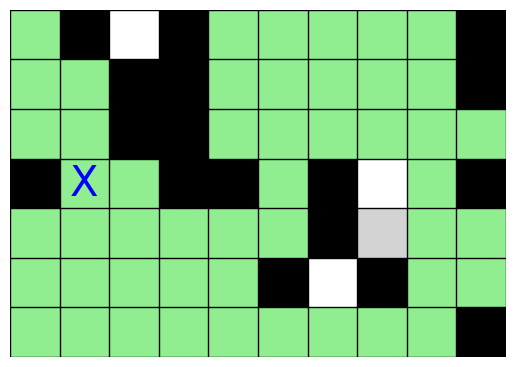

Action = right

State 72


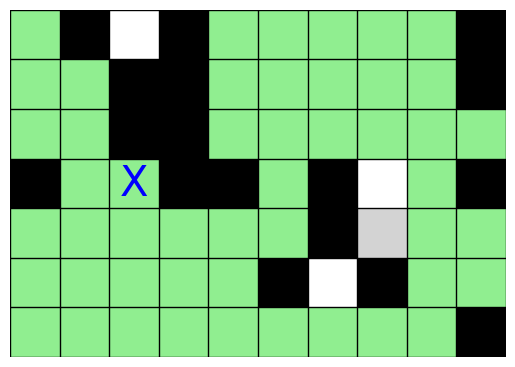

Action = down

State 73


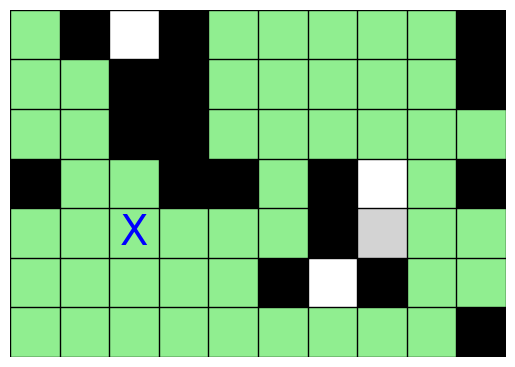

Action = right

State 74


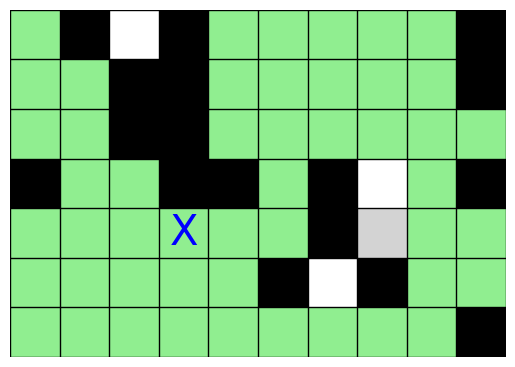

Action = right

State 75


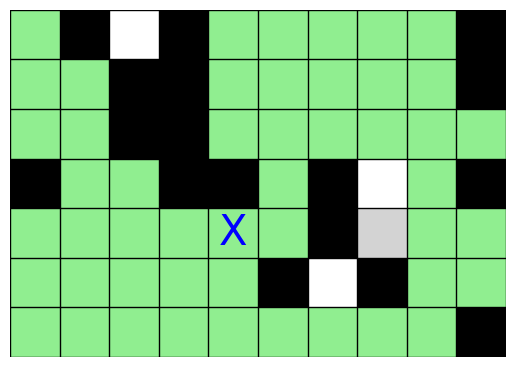

Action = right

State 76


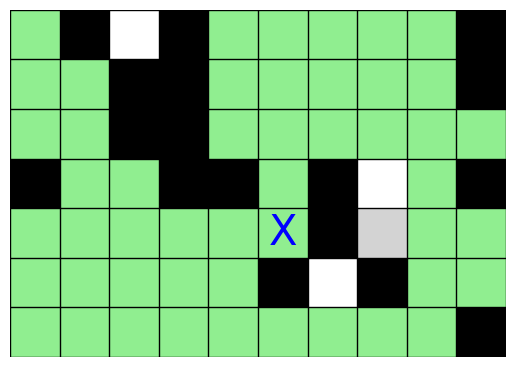

Action = up

State 77


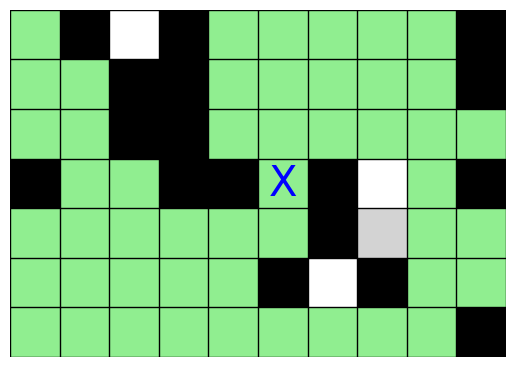

Action = up

State 78


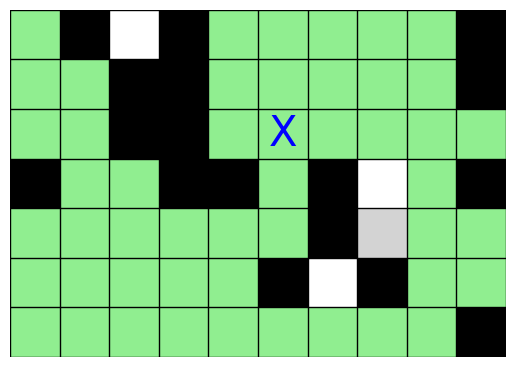

Action = right

State 79


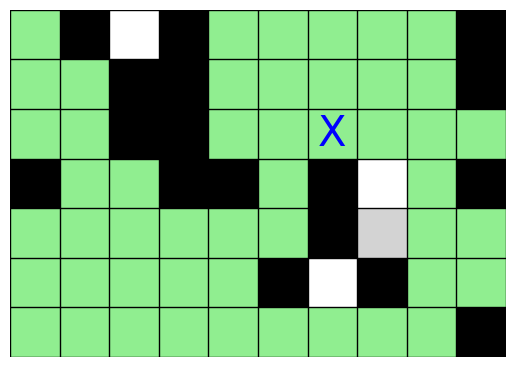

Action = right

State 80


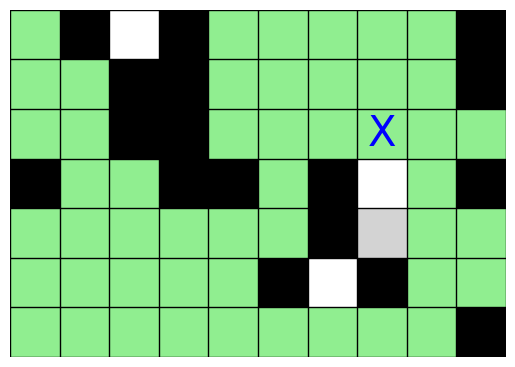

Action = down

State 81


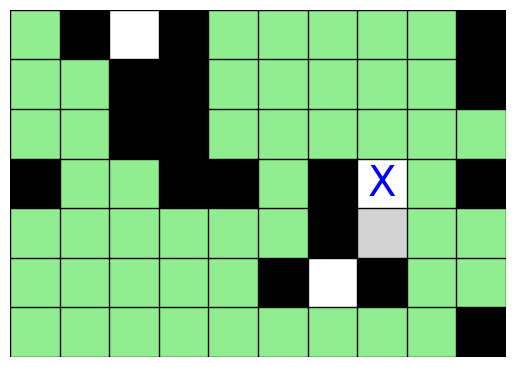

Action = down

State 82


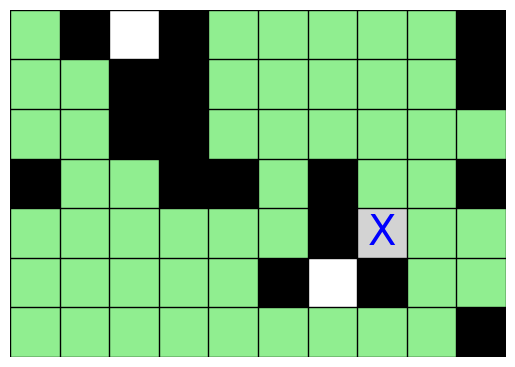

Action = clean

State 83


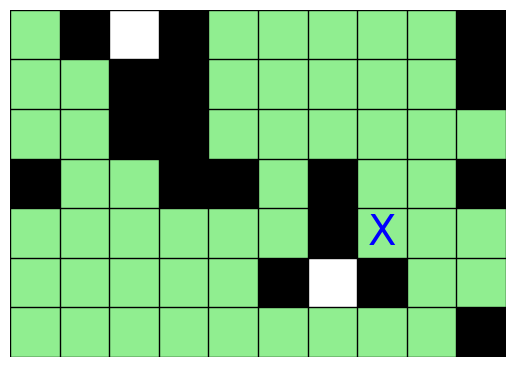

Action = up

State 84


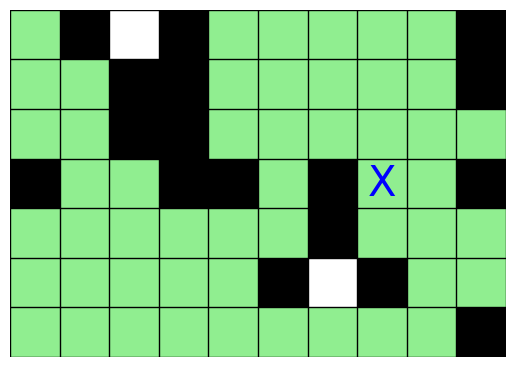

Action = up

State 85


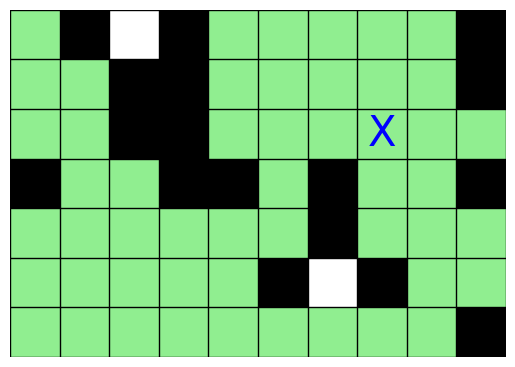

Action = up

State 86


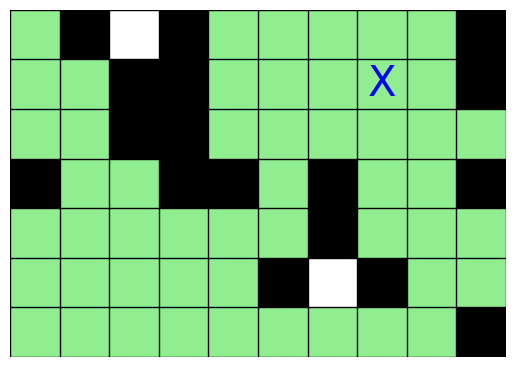

Action = left

State 87


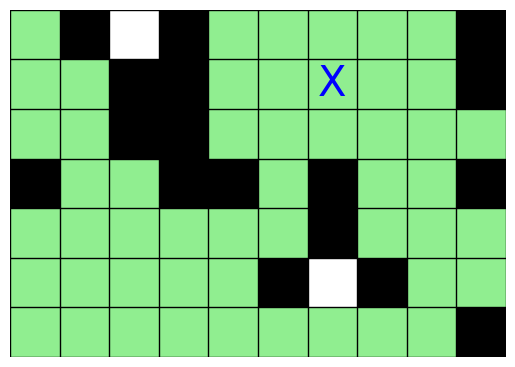

Action = left

State 88


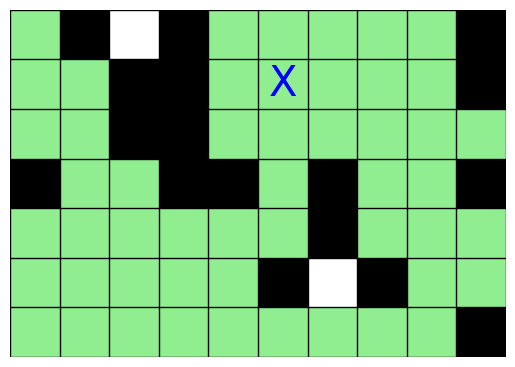

Action = left

State 89


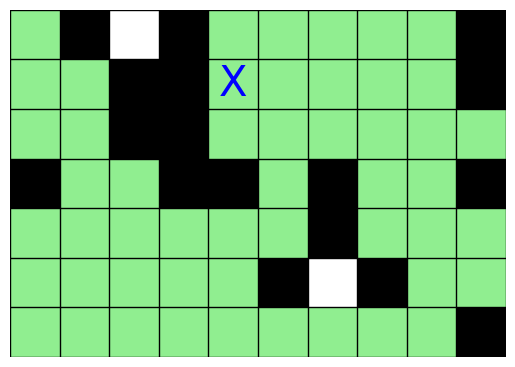

Action = up

State 90


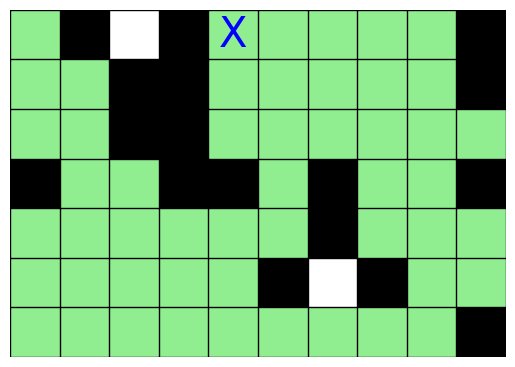

Action = right

State 91


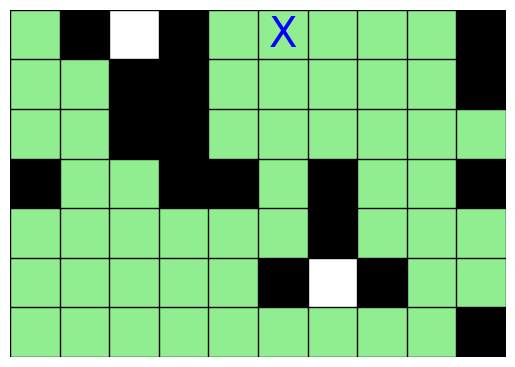

Action = right

State 92


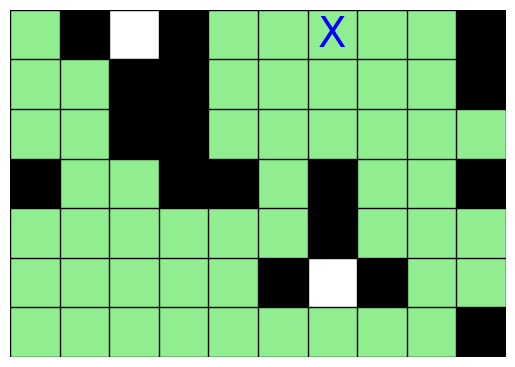

Action = right

State 93


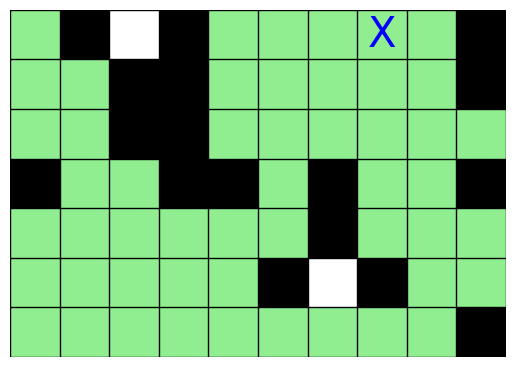

Action = right

State 94


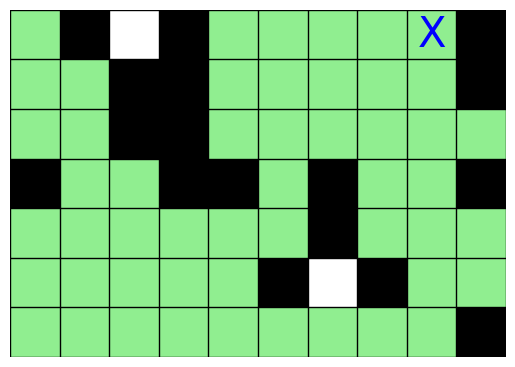

Action = down

State 95


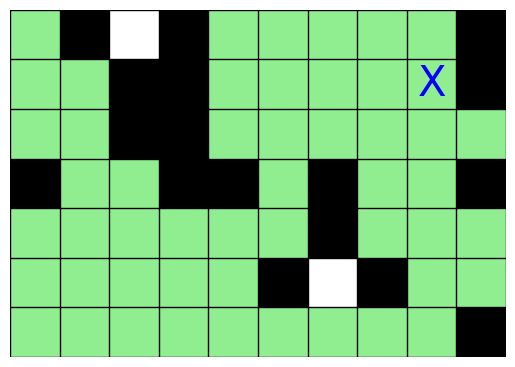

Action = down

State 96


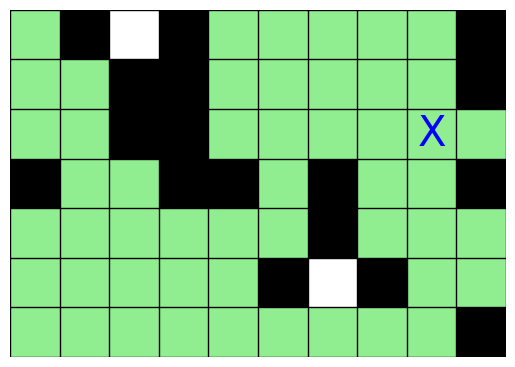

Action = down

State 97


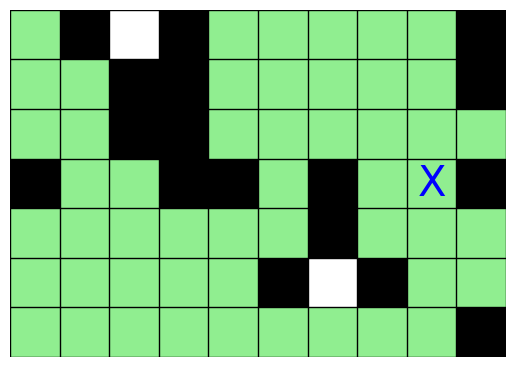

Action = down

State 98


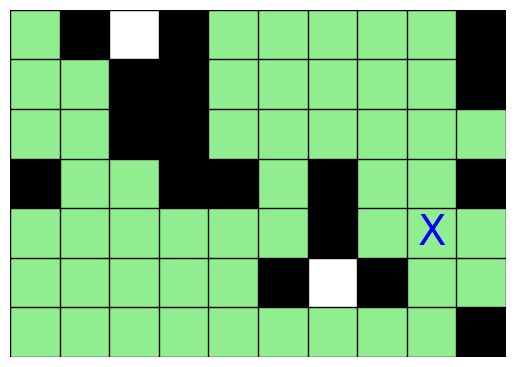

Action = right

State 99


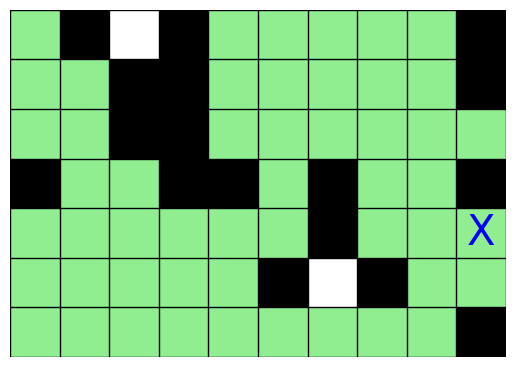

Action = down

State 100


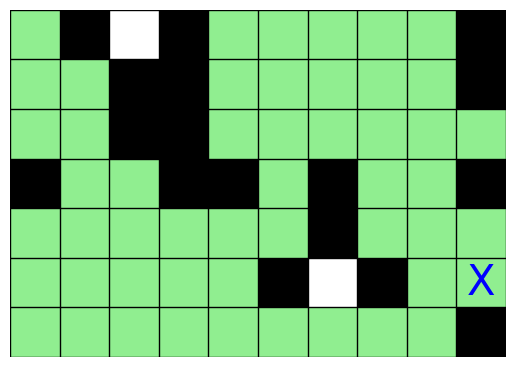

Action = left

State 101


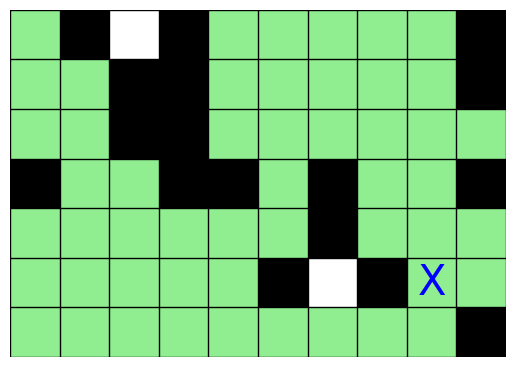

Action = down

State 102


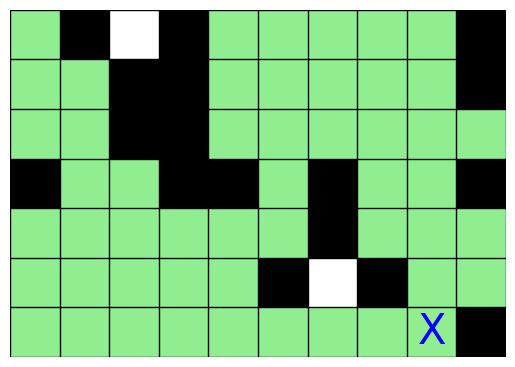

Action = left

State 103


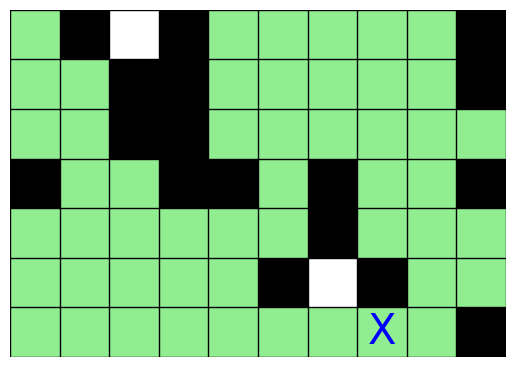

Action = left

State 104


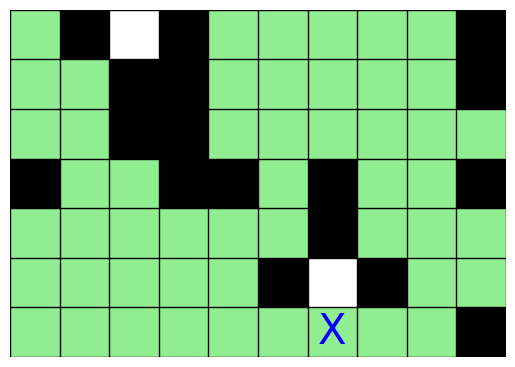

Action = up

State 105


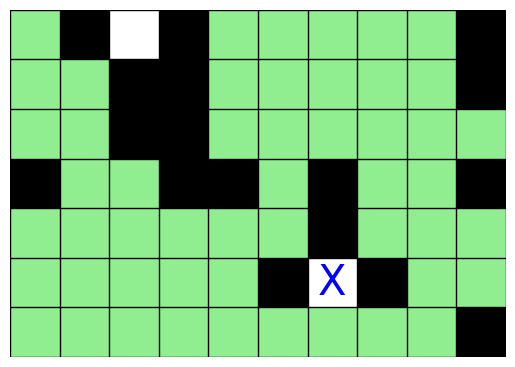

Action = down

State 106


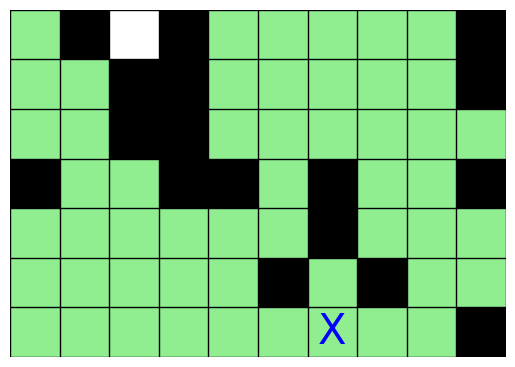

Action = left

State 107


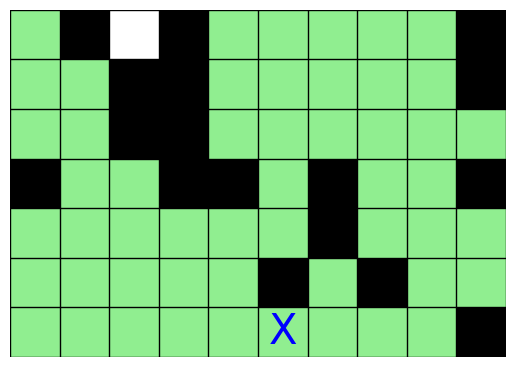

Action = left

State 108


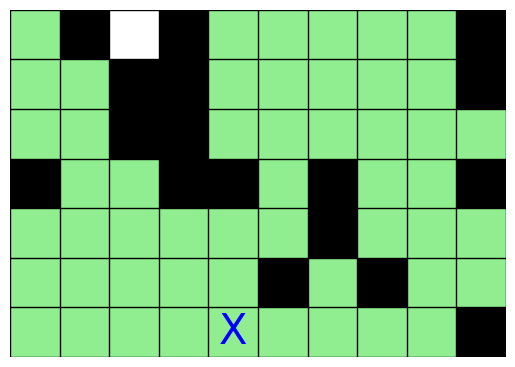

Action = left

State 109


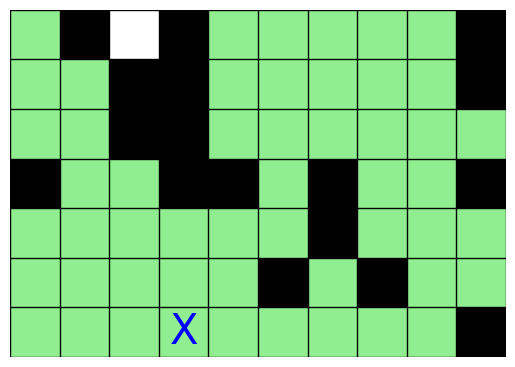

Action = left

State 110


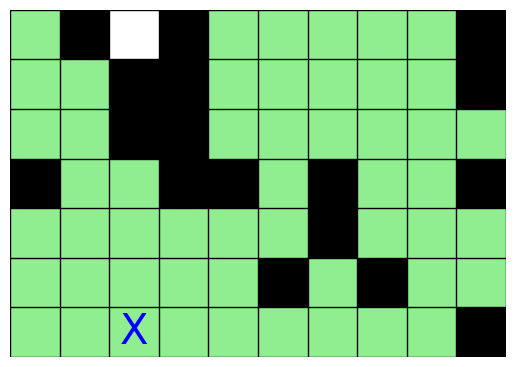

Action = left

State 111


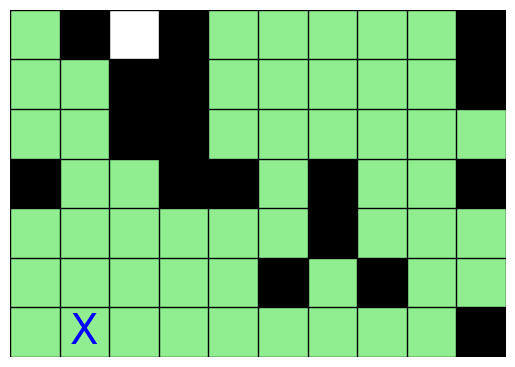

Action = left

State 112


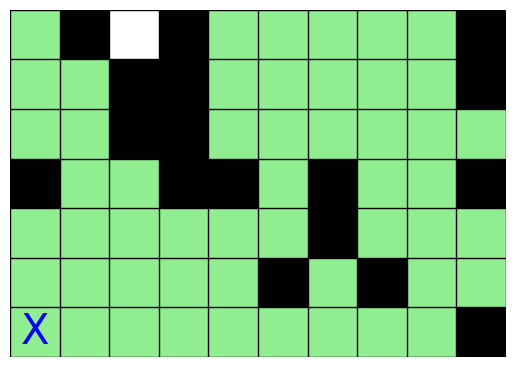

Action = stop

Dirt percentage (%): 0.0
Steps taken: 113


In [13]:
#environment = Environment(5, 5, 4321)
#environment = Environment(8, 8, 666)
#environment = Environment(4, 12, 911)
#environment = Environment(6, 6, 42)
environment = Environment(7, 10, 3141592)
agent = Agent(567)
agent.start(environment, 1000) # You can adjust the maximum number of steps. This is just a safety condition.
steps, dirt = environment.evaluate()
print("Dirt percentage (%): " + str(round(dirt * 100, 2)))
print("Steps taken: " + str(steps))